In [33]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from library import *
from scipy.stats import norm
from scipy import linalg
from math import *
#from corrs20x20 import * 
from corrs5x5 import *

# Check correlation matrix

In [19]:
rho = np.asarray(Corrs)

In [20]:
def checkSymmetric(a):
    
    return np.all( np.abs(a - a.T) < 1.e-08 )

def isValidCorr(a):
    if not checkSymmetric(a) :
        raise QFError("Matrix is NOT symmetric")

    eigval, eigvec = linalg.eig(a)
    m = np.min(eigval)
    print("@ %-12s: Min(eigenvalue) = (%.4f  + %.4f i)\n" %("Info", m.real, m.imag))
    if m.real <= 0: raise QFError("Negative eigenvalue")

In [21]:
isValidCorr(rho)

@ Info        : Min(eigenvalue) = (0.0029  + 0.0000 i)



# Martingale check



@ Info        : type(C)      <class 'numpy.ndarray'>

@ Info        : J               16384

@ Info        : Nt                 12

@ Info        : Sigma        
[0.370367 0.445588 0.398324 0.380405 0.377829 0.448265 0.435559 0.450125
 0.353118 0.429132 0.44069  0.368316 0.392728 0.306113 0.372613 0.368394
 0.339283 0.403478 0.415147 0.349894]


@ Info        : executed inner_step_test       elapsed   3.8507e+00 sec.


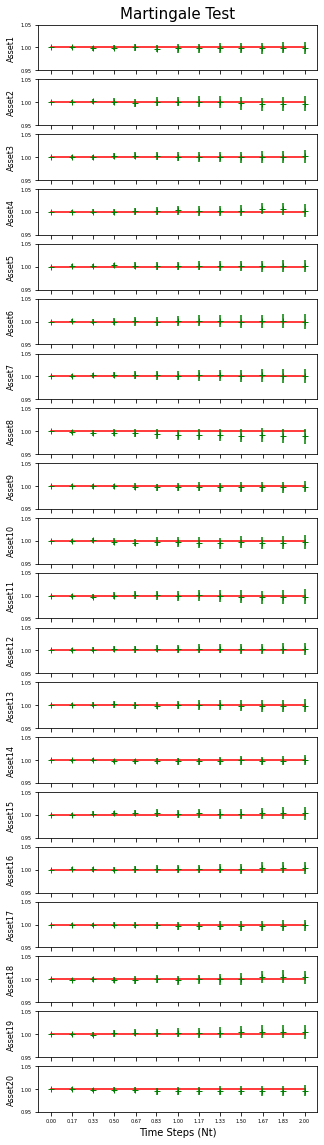

In [22]:
sigma = np.asarray(Vols)

rand = np.random.RandomState()
rand.seed(1907)

martingale_test(Rho = rho, sigma = sigma )

# Discount curve

In [23]:
discount_curve = pd.read_csv("market_discount_factor.csv",  sep = ';')

In [24]:
t = np.asarray(discount_curve["Times"])
P = np.asarray(discount_curve["P_0t"])
dc = Zc.from_discount_curve(t,P)

In [25]:
def show_interpolated_curve(dc,T, Nb):

    times = np.linspace(0, T, Nb, endpoint = True)
    
    n = 0
    print("\n")
    print("%3s  %9s  %8s  %8s  %8s\n" %("n", "t", "P_0t", "r", "ry") )
    for t in times:
        print("%3d  %9.6f  %8.6f  %8.6f  %8.6f" %(n, t, dc.P_0t(t), dc.rz(t), dc.ry(t)) )
        n += 1

    print("#-\n")

def interpolated_P0t(dc, T, Nb):

    times = np.linspace(0, T, Nb, endpoint = True)
    P_0t = np.ndarray(shape = (len(times),), dtype = "f" )

    k = 0
    for t in times:
        P_0t[k] = dc.P_0t(t)
        k += 1

    return P_0t

In [26]:
show_interpolated_curve(dc, 2, 25)



  n          t      P_0t         r        ry

  0   0.000000  1.000000       nan       nan
  1   0.083333  0.998412  0.019071  0.019254
  2   0.166667  0.996581  0.020549  0.020761
  3   0.250000  0.994674  0.021360  0.021590
  4   0.333333  0.992091  0.023822  0.024108
  5   0.416667  0.989390  0.025599  0.025930
  6   0.500000  0.986697  0.026784  0.027146
  7   0.583333  0.983593  0.028359  0.028765
  8   0.666667  0.980430  0.029647  0.030091
  9   0.750000  0.977276  0.030649  0.031123
 10   0.833333  0.974132  0.031450  0.031950
 11   0.916667  0.970999  0.032106  0.032627
 12   1.000000  0.967875  0.032652  0.033191
 13   1.083333  0.965014  0.032873  0.033419
 14   1.166667  0.962221  0.033009  0.033560
 15   1.250000  0.959436  0.033128  0.033683
 16   1.333333  0.956659  0.033231  0.033790
 17   1.416667  0.953890  0.033323  0.033884
 18   1.500000  0.951129  0.033404  0.033968
 19   1.583333  0.948376  0.033477  0.034043
 20   1.666667  0.945631  0.033542  0.034111
 21   1

C:\Users\Utente\Desktop\COMPUTATIONAL FINANCE\EXAM\library.py:657: RuntimeWarning: invalid value encountered in double_scalars
  def rz( self, t): return self.f_0t(t)/t
C:\Users\Utente\Desktop\COMPUTATIONAL FINANCE\EXAM\library.py:658: RuntimeWarning: invalid value encountered in double_scalars
  def ry( self, t): return exp(self.f_0t(t)/t) - 1.


In [27]:
# TEST FOR VALID DISCOUNT CURVE

P0t = interpolated_P0t(dc, 2, 25)

def check_increasing_discount(P0t):
    if np.all(np.diff(P0t) < 0):
        print("The zero coupon bond prices are strictly decreasing with respect to maturity.")
    else:
        print("The discount curve is not valid.")

check_increasing_discount(P0t)

P0t


The zero coupon bond prices are strictly decreasing with respect to maturity.


array([1.        , 0.998412  , 0.9965811 , 0.9946742 , 0.99209064,
       0.98939025, 0.9866972 , 0.98359346, 0.98042953, 0.9772757 ,
       0.97413206, 0.9709985 , 0.96787506, 0.9650145 , 0.9622212 ,
       0.959436  , 0.9566589 , 0.9538898 , 0.9511287 , 0.94837564,
       0.94563055, 0.9428934 , 0.9401641 , 0.9374428 , 0.9347293 ],
      dtype=float32)

In [28]:
def t_default(S, T, Nt, Nb, thres):

    '''
    Returns an array of shape (J,Q) containing the first month in
    which an asset satisfies the default condition for each trajectory

    @ S          multidemensional BS trajectories
    @ T          maturity
    @ Nt         number of time steps in the underlying trajectories    
    @ Nb         number of time steps for coupon payments
    @ thres      percentage of initial value below which a default happens
    '''

    mask = np.where(S/S[0] < thres, False, True)
    
    # Returns the time index of the first default for each asset and trajectory
    t_default = np.argmin(mask, axis = 0)

    # Translates the time indexes into monthly figures
    if Nt % Nb != 0:
        t_default = np.ceil( t_default / (Nt / Nb) )

    return t_default

In [29]:
# TEST TIMES DEFAULT

sigma = np.asarray(Vols)
C = linalg.cholesky(rho)
So = np.ones(shape = (len(sigma),), dtype = "f")
rand  = np.random.RandomState()
rand.seed(1907)
T = 2
J = (1 << 14)
Nt = 104
S5 = BSn_trj(rand, Nt, So, C, sigma, T, J)

times_default = t_default(S5, 2, 104, 24, .8)
np.count_nonzero(times_default)
times_default

array([[ 6.,  0.,  3., ...,  0.,  0.,  0.],
       [ 6.,  0.,  1., ...,  0.,  0.,  0.],
       [ 4.,  1.,  0., ...,  0., 20., 10.],
       ...,
       [ 0.,  6., 16., ..., 15.,  0., 18.],
       [ 3.,  3.,  7., ..., 16., 22., 13.],
       [ 0.,  0.,  4., ...,  6.,  0.,  4.]])

In [30]:
def cum_counter(Nb, Nt, J, S, T, thres):
    
    '''
    Returns an array of dimensions (Nb, J) containing the cumulative percentage 
    of defaulted assets at each time step
    '''

    times_default = t_default(S, T, Nt, Nb, thres)

    cum_counter = np.zeros(shape = (Nb, J)) 
    counter = np.zeros(shape = (J,))

    for n in range(Nb):
        
        # we rule out 0 valued times of default
        counter += np.count_nonzero(times_default == n + 1, axis = 1) / np.shape(S)[2]
        cum_counter[n] = counter
    
    return cum_counter


In [31]:
# TEST FOR THE CUM_COUNTER
a = np.asarray([[9,0,3,0,10],
            [5, 4, 0, 11, 0]])

np.count_nonzero(a == 0, axis = 1)
Nb = 12
test_cum_counter = np.zeros(shape = (Nb, 2)) 
test_counter = np.zeros(shape = (2,))

for n in range(Nb):
    test_counter += np.count_nonzero(a == n + 1, axis = 1) / 5
    test_cum_counter[n] = test_counter 

test_cum_counter

#loss = (test_cum_counter - 0.2)/(0.4 - 0.2)
#mask1 = np.where(loss > 0, loss, 0)
#mask2 = np.where(mask1< 1, mask1, 1)
#mask2

array([[0. , 0. ],
       [0. , 0. ],
       [0.2, 0. ],
       [0.2, 0.2],
       [0.2, 0.4],
       [0.2, 0.4],
       [0.2, 0.4],
       [0.2, 0.4],
       [0.4, 0.4],
       [0.6, 0.4],
       [0.6, 0.6],
       [0.6, 0.6]])

In [34]:
# TEST DEFAULT

sigma_5 = np.asarray(Vols)
rho_5   = np.asarray(Corrs)
C_5     = linalg.cholesky(rho_5)
So_5    = np.ones(shape = (len(sigma_5),), dtype = "f")

rand  = np.random.RandomState()
rand.seed(1907)

T = 1
J = 2
Nt = 52
Nb = 12
thres = .8
S_5 = BSn_trj(rand, Nt, So_5, C_5, sigma_5, T, J)

test_t_default = t_default(S_5, T, Nt, Nb, thres)
#test_t_default

# TEST FOR THE CUM COUNTER
test_cum_counter = cum_counter(Nb, Nt, J, S_5, T, thres)
print(f"Times of default:\n\n{test_t_default}\n\nCumulative defaults:\n\n{test_cum_counter}")

Times of default:

[[0. 4. 0. 0. 0.]
 [1. 5. 0. 3. 0.]]

Cumulative defaults:

[[0.  0.2]
 [0.  0.2]
 [0.  0.4]
 [0.2 0.4]
 [0.2 0.6]
 [0.2 0.6]
 [0.2 0.6]
 [0.2 0.6]
 [0.2 0.6]
 [0.2 0.6]
 [0.2 0.6]
 [0.2 0.6]]


In [15]:
def tranches(R, att, det, Nb, Nt, T, cal_N, J, thres, So, sigma, C, dc, Seed):

    '''
    Computes the payoffs of junior, mezzanine and senior tranche for each simulation

    @ R          tuple of coupon rates for each class of risk
    @ att        tuple of tranche attachments
    @ det        tuple of tranche detachments
    @ Nb         number of time steps for coupon payments
    @ Nt         number of time steps in the underlying trajectories
    @ T          maturity
    @ cal_N      notional
    @ J          number of MC simulations
    @ thres      default threshold
    @ So         array of underlyings' starting prices
    @ sigma      array of volatilities
    @ C          cholesky matrix
    @ dc         discount curve object
    @ Seed       random seed
    '''
    
    rand = np.random.RandomState()
    rand.seed(Seed)
    M = BSn_trj(rand, Nt, So, C, sigma, T, J)

    P0t = interpolated_P0t(dc, T, Nb + 1)[1:]
    
    # From martingale M to S
    D_tT = interpolated_P0t(dc, T, Nt + 1) 
    S = np.einsum('ijk,i -> ijk', M, 1/D_tT)

    tau = T/Nb
    cum_defaults = cum_counter(Nb, Nt, J, S, T, thres)

    loss = np.ndarray(shape = (Nb, J))

    loss   = {}
    mask1  = {}
    mask2  = {}
    payoff = {}

    for i in range(3):

        # computes the loss that affects only the i-th tranche
        loss[i] = (cum_defaults - att[i])/(det[i] - att[i])

        # losses greater than 1 are set to 1, while negative losses are set to 0
        mask1[i] = np.where(loss[i] > 0, loss[i], 0)
        mask2[i] = np.where(mask1[i] < 1, mask1[i], 1)

        # cash flows at each time step
        payoff[i]  = np.einsum('j,jk -> jk', P0t * tau * R[i] * cal_N , (1-mask2[i]))
        payoff[i][-1] +=  P0t[-1] * cal_N * (1-mask2[i][-1])

        payoff[i] = np.sum(payoff[i], axis = 0)
 
    return payoff[0],payoff[1], payoff[2]    

In [16]:
def mc_securitization(**kwargs ):

    R          = kwargs.get("R", (.075, .025, .012))
    att        = kwargs.get("att", (.0, .2, .4))
    det        = kwargs.get("det", (.2, .4, 1))
    Nb         = kwargs.get("Nb", 24)
    Nt         = kwargs.get("Nt", 104)
    T          = kwargs.get("T", 2)
    cal_N      = kwargs.get("cal_N", 100)
    Js         = kwargs.get("Js",(14,16, 18, 20))
    thres      = kwargs.get("thres", .20)
    Seed       = kwargs.get("Seed", 1907)
    So         = kwargs["So"]
    sigma      = kwargs["sigma"]
    C          = kwargs["C"]
    dc         = kwargs["dc"]

    print("@ %25s %8s %9s" %("junior", "mezzan", "senior"))
    print("@ %-16s %8.3f %8.3f %8.3f"  %("R", R[0], R[1], R[2]))
    print("@ %-16s %8.3f %8.3f %8.3f"  %("attachment", att[0], att[1], att[2]))
    print("@ %-16s %8.3f %8.3f %8.3f\n"  %("detachment", det[0], det[1], det[2]))
    print("@ %-16s %8.4f"  %("Nb", Nb))
    print("@ %-16s %8.4f"  %("Nt", Nt))
    print("@ %-16s %8.4f"  %("T", T))
    print("@ %-16s %8.4f"  %("Notional", cal_N))
    print("@ %-16s %8.4f"  %("Default treshold", thres))
    print("\n")
    
    junior    = {}
    mezzanine = {}
    senior    = {}

    T0 = Timer()
    for j in Js:
        T0.start()
        J = ( 1 << j )
        ju, me, se   = tranches(R, att, det, Nb, Nt, T, cal_N, J, thres, So, sigma, C, dc, Seed)
        junior[j]    = ju
        mezzanine[j] = me
        senior[j]    = se
        T1 = T0.stop()
        print("@ elapsed time for %6d iterations: %2.5f sec." %(J, T1))
    print("\n")

    # Junior
    print("%9s    %12s %3s %12s" %("J", "Junior", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = junior[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")

    # Mezzanine
    print("%9s    %12s %3s %12s" %("J", "Mezzanine", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = mezzanine[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n")    

    # Senior
    print("%9s    %12s %3s %12s" %("J", "Senior", "+/-", "MC-err"))
    for j in Js:
        J = ( 1 << j )
        x = senior[j]
        m, S2 = stats(x)
        err   = S2/sqrt(J)
        print("%9d    %12.6f %3s %12.4e" %( J, m, "+/-", err))
    print("\n#----\n") 
    
    
    

In [17]:
rho = np.asarray(Corrs)
C   = linalg.cholesky(rho)

sigma = np.asarray(Vols)
So = np.ones(shape = (len(sigma),), dtype = "f")

mc_securitization(So = So, Nt = 24, sigma = sigma, C = C, dc = dc, thres = .2, Js = (14, 16, 18, 20))

@                    junior   mezzan    senior
@ R                   0.075    0.025    0.012
@ attachment          0.000    0.200    0.400
@ detachment          0.200    0.400    1.000

@ Nb                24.0000
@ Nt                24.0000
@ T                  2.0000
@ Notional         100.0000
@ Default treshold   0.2000


@ elapsed time for  16384 iterations: 2.46972 sec.
@ elapsed time for  65536 iterations: 10.63343 sec.
@ elapsed time for 262144 iterations: 49.22913 sec.


MemoryError: Unable to allocate 3.75 GiB for an array with shape (24, 1048576, 20) and data type float64

In [ ]:
# TEST THE SPEED OF THE TRAJECTORIES GENERATOR
T0 = Timer()
rand = np.random.RandomState()
rand.seed(1907)
for j in (4, 6, 8, 10):
    T0.start()
    n_traj = BSn_trj(Obj = rand, Nt = 24, So = np.ones(shape = (len(sigma),), dtype = "f"), C = C, sigma = sigma,  T = 2, J = (1<<j))
    T1 = T0.stop()
print("@ elapsed time for %6d iterations: %2.5f sec." % ((1<<j), T1))
